<a href="https://colab.research.google.com/github/gdconstantino2/Arduino/blob/main/T1_Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 — Clasificación de piezas LEGO
**IIC2613 Inteligencia Artificial — 2026**

Este notebook contiene únicamente la **carga de datos** y algunas celdas de **referencia**. Todo el
desarrollo (extracción de features, modelos y análisis) lo implementas **tú**, siguiendo el enunciado.

- Entrega el notebook con **todas las celdas ejecutadas**.
- Mantén `piezas_dataset.csv` **junto al notebook** (en el repo).
- Modelos permitidos: **clásicos** (SVM, Random Forest, Árbol de Decisión, KNN, etc.) — *sin deep learning*.

In [1]:
import os, re, glob, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from PIL import Image
try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42
np.random.seed(SEED)
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    return np.asarray(Image.open(path).convert('L').resize((size, size)), dtype=np.uint8)

## Track A — Clasificación a partir de imágenes

Las siguientes celdas **descargan y preparan las imágenes**: carga y organización, análisis exploratorio
y una **segmentación de referencia**. **Ejecútalas** y luego desarrolla tu solución según el enunciado.

In [2]:
# === Carga y organización de imágenes (ejecutar) ===
CSV_PATH = 'piezas_dataset.csv'      # manifiesto de piezas (su ficha técnica se usa en la Parte 2)
WORK_DIR = 'data'

def find_images(root):
    return sorted(glob.glob(os.path.join(root, '**', '*.png'), recursive=True))

def get_data_root():
    # 1) copia local junto al notebook (carpeta plana 'dataset/')
    for cand in ['dataset', os.path.join('LEGO brick images', 'dataset')]:
        if os.path.isdir(cand) and glob.glob(os.path.join(cand, '*.png')):
            return cand
    # 2) Kaggle vía kagglehub (Colab). Si pide login, ejecuta antes: kagglehub.login()
    try:
        import kagglehub
    except ImportError:
        os.system('pip -q install kagglehub'); import kagglehub
    path = kagglehub.dataset_download('joosthazelzet/lego-brick-images')
    flat = os.path.join(path, 'dataset')
    return flat if os.path.isdir(flat) else path

assert os.path.exists(CSV_PATH), (
    'No se encuentra ' + CSV_PATH + '. Debe estar en la misma carpeta que este notebook '
    '(en Colab: súbelo o monta el repositorio).')
manifest = pd.read_csv(CSV_PATH, usecols=['filename', 'label'])
RAW_DIR = get_data_root()
avail = {os.path.basename(p): p for p in find_images(RAW_DIR)}
print('Fuente de imágenes:', RAW_DIR, '|', len(avail), 'archivos .png encontrados')

if os.path.isdir(WORK_DIR):
    shutil.rmtree(WORK_DIR)
paths, faltantes = [], 0
for _, r in manifest.iterrows():
    dest = avail.get(r['filename'])
    if dest is None:
        paths.append(None); faltantes += 1; continue
    dest_dir = os.path.join(WORK_DIR, str(r['label']))
    os.makedirs(dest_dir, exist_ok=True)
    destino = os.path.join(dest_dir, r['filename'])
    shutil.copy(dest, destino)
    paths.append(destino)

df = manifest.copy()
df['path'] = paths
if faltantes:
    print('ADVERTENCIA:', faltantes, 'de', len(manifest),
          'imágenes del CSV no aparecieron en', RAW_DIR)
df = df[df['path'].notna()].reset_index(drop=True)

# Si algo salió mal, es mejor fallar acá que arrastrar un dataset incompleto.
assert len(df) > 0, (
    'No se copió ninguna imagen. Revisa que la descarga haya terminado y que RAW_DIR apunte a '
    'la carpeta con los .png. Si el problema persiste, avísanos por una issue.')
assert df['label'].nunique() == manifest['label'].nunique(), (
    'Faltan clases completas: se esperaban ' + str(manifest['label'].nunique()) +
    ' piezas y quedaron ' + str(df['label'].nunique()) + '.')

clases = sorted(df['label'].unique())
print('Piezas a clasificar:', len(clases))
print('Imágenes organizadas en', WORK_DIR + '/:', len(df))
display(df['label'].value_counts())


Using Colab cache for faster access to the 'lego-brick-images' dataset.
Fuente de imágenes: /kaggle/input/lego-brick-images/dataset | 40000 archivos .png encontrados
Piezas a clasificar: 8
Imágenes organizadas en data/: 2400


,count
label,
3040 roof tile 1x2,300
3004 brick 1x2,300
3062 Round Brick 1x1,300
3001 brick 2x4,300
3022 Plate 2x2,300
3005 brick 1x1,300
3069 Flat Tile 1x2,300
3003 brick 2x2,300


### Análisis exploratorio

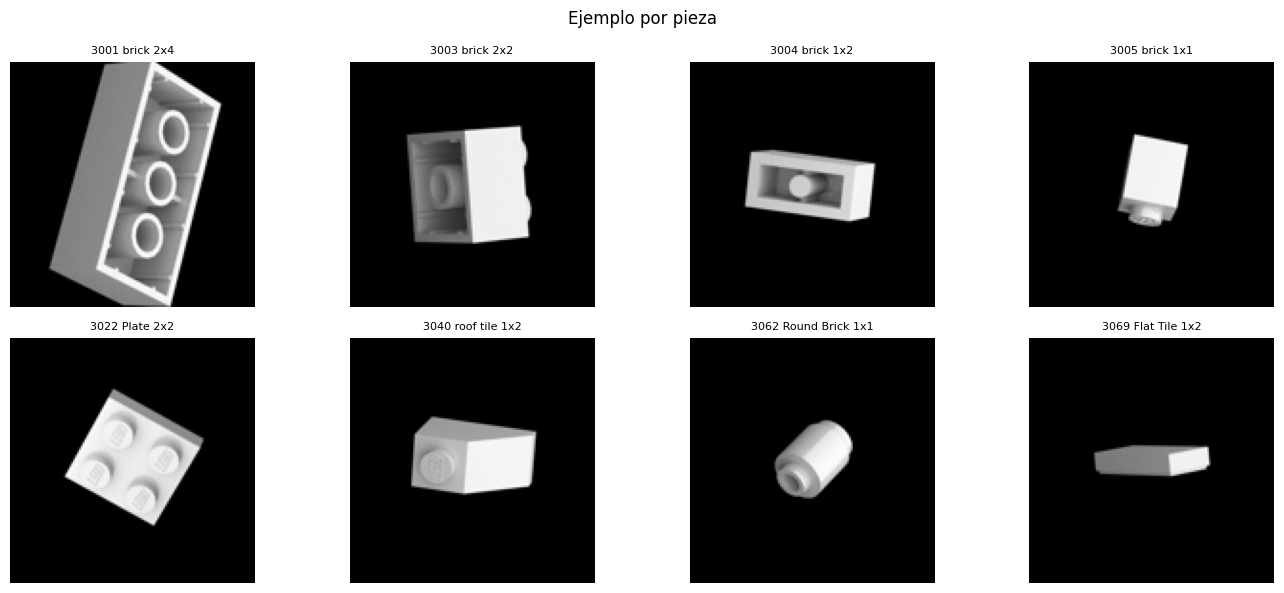

In [3]:
# === EDA: una imagen de ejemplo por pieza ===
n = len(clases)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(14, 6))
for ax, c in zip(axes.ravel(), clases):
    ax.imshow(load_gray(df[df.label == c].iloc[0].path), cmap='gray')
    ax.set_title(c, fontsize=8); ax.axis('off')
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.suptitle('Ejemplo por pieza'); plt.tight_layout(); plt.show()

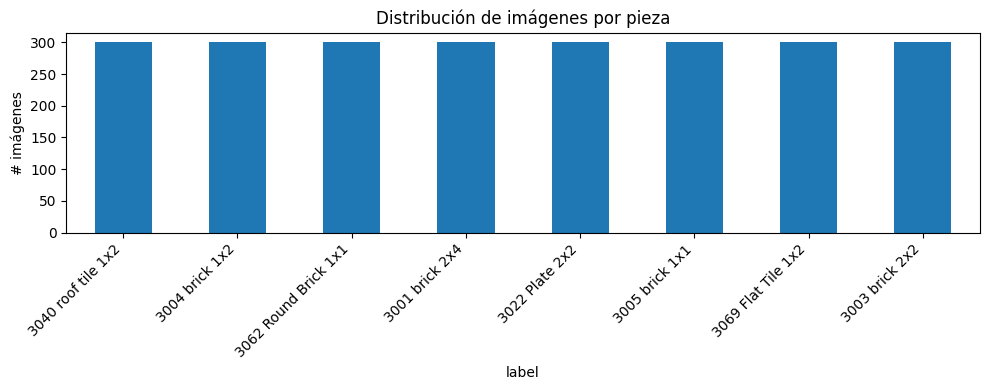

In [4]:
# === EDA: distribución de imágenes por pieza ===
plt.figure(figsize=(10, 4))
df.label.value_counts().plot(kind='bar')
plt.title('Distribución de imágenes por pieza'); plt.ylabel('# imágenes')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### Preprocesamiento y segmentación (referencia)

Las imágenes son monocromas: la **forma** es lo que distingue a las piezas. La función `segment`
separa la pieza del fondo y devuelve una **máscara** binaria; puedes usarla como base para construir
tus características. Es solo una referencia: puedes modificarla o reemplazarla.

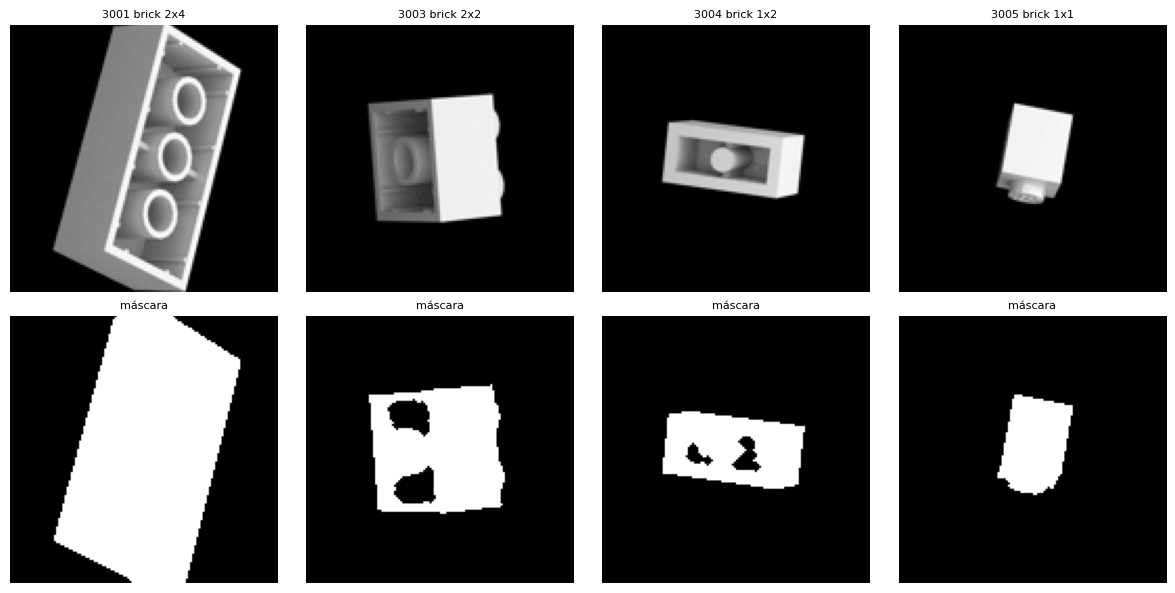

In [5]:
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk

def segment(img):
    border = np.concatenate([img[0, :], img[-1, :], img[:, 0], img[:, -1]])
    bg = np.median(border)
    diff = np.abs(img.astype(int) - bg).astype(np.uint8)
    try:
        t = threshold_otsu(diff)
    except Exception:
        t = 10
    mask = diff > max(int(t), 10)
    mask = binary_closing(mask, disk(2))
    mask = remove_small_objects(mask, 50)
    return mask

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, c in enumerate(clases[:4]):
    img = load_gray(df[df.label == c].iloc[0].path)
    m = segment(img)
    axes[0, i].imshow(img, cmap='gray'); axes[0, i].set_title(c, fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(m, cmap='gray'); axes[1, i].set_title('máscara', fontsize=8); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

### Tu desarrollo — Track A

Desde aquí en adelante, **implementa tu solución** (agrega las celdas que necesites) según el enunciado:
extracción de características (con fuentes), escalado/normalización, división train/test y el
entrenamiento y comparación de los 4 modelos con sus combinaciones de hiperparámetros.

> **Importante:** la partición *train*/*test* que definas acá es la que debes **reutilizar en los
> Track B y C** (mismos índices, misma semilla). Los tres tracks se comparan entre sí, y esa
> comparación solo es válida si los modelos se evalúan sobre el mismo conjunto de prueba.


In [6]:
from skimage.measure import label, regionprops
def extraer_features(df, i):
    filename = df.iloc[i]['filename']
    label_val = df.iloc[i]['label']
    imagem = load_gray(df.iloc[i]['path'], 128)
    ver = segment(imagem)
    imagem_rotulada = label(ver)
    region = regionprops(imagem_rotulada)
    circularidade = 0
    if region:
      maior_region = max(region, key=lambda x: x.area)
      min_row, min_col, max_row, max_col = maior_region.bbox
      altura = max_row - min_row
      largura = max_col - min_col
      eccentricity = maior_region.eccentricity
      perimetro = maior_region.perimeter
      if perimetro > 0:
        circularidade = (4 * np.pi * maior_region.area) / (perimetro ** 2)
      else:
        circularidade = 0
      res =  {'filename': filename,
        'label': label_val,
        'area': maior_region.area,
        'solidity': maior_region.solidity,
        'eccentricity': eccentricity,
        'circularidade' : circularidade,
        'altura': altura,
        'largura': largura,
        'aspect_ratio': largura / altura }
      for idx, hu_val in enumerate(maior_region.moments_hu):
        res[f'hu_{idx}'] = hu_val

      return res

    else:
      res = {
        'filename': filename,
        'label': label_val,
        'area': 0,
        'solidity': 0,
        'eccentricity': 0,
        'circularidade' : circularidade,
        'altura': 0,
        'largura': 0,
        'aspect_ratio': 0,
    }
      for idx in range(7):
        res[f'hu_{idx}'] = 0
      return res


In [7]:
#EXTRAINDO OS VALORES PARA DEPOIS USAR COM ALGUM MOMENTO DE HU, HOG OU LBP
lista_de_recursos = []

for i in range(len(df)):
    dic_features = extraer_features(df, i)
    lista_de_recursos.append(dic_features)

df_final = pd.DataFrame(lista_de_recursos)
df_final.to_csv('features_separadas.csv', index = False)

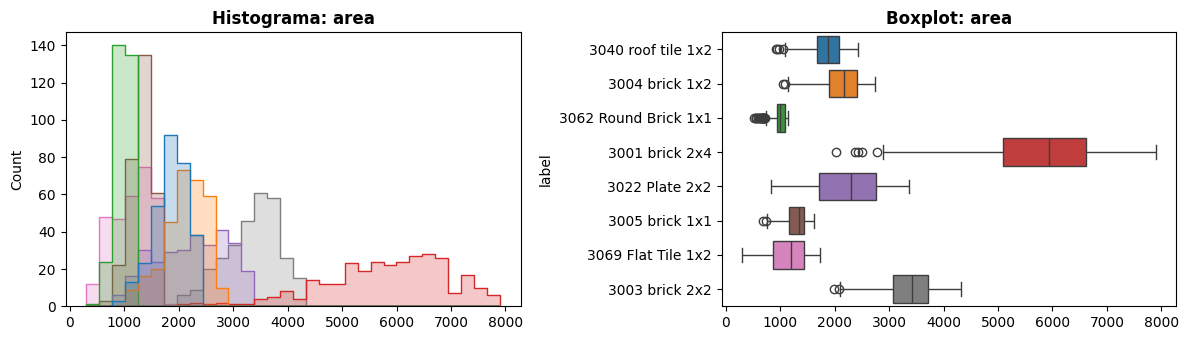

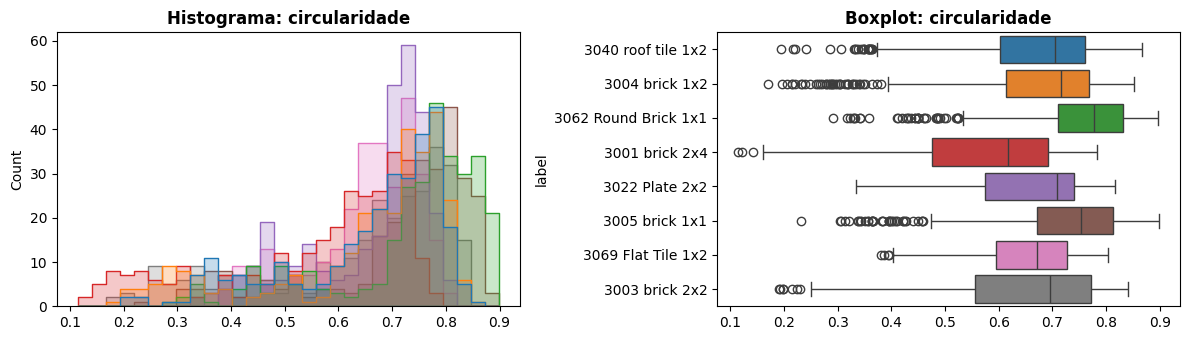

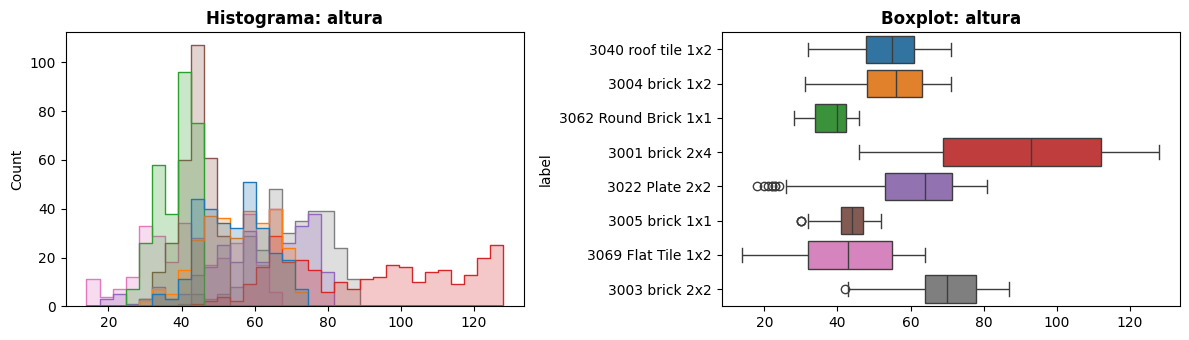

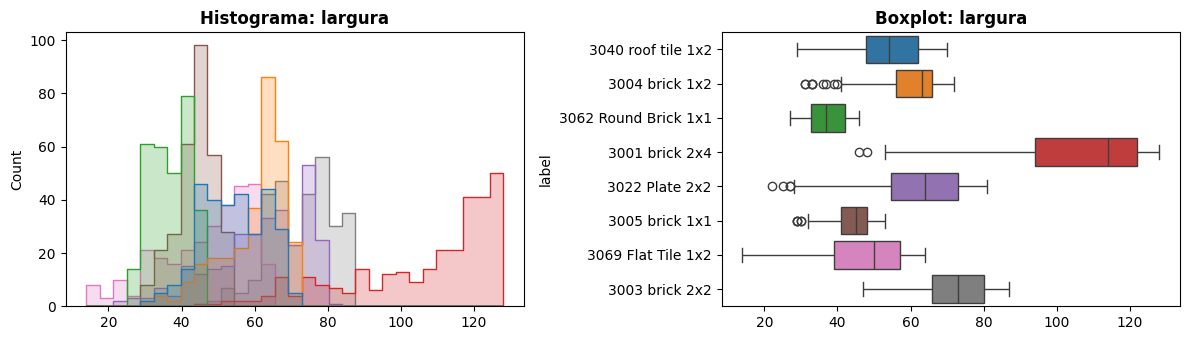

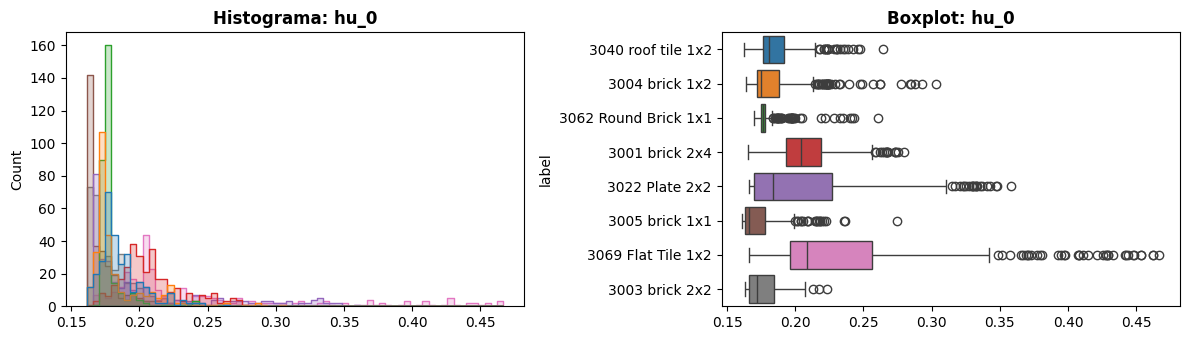

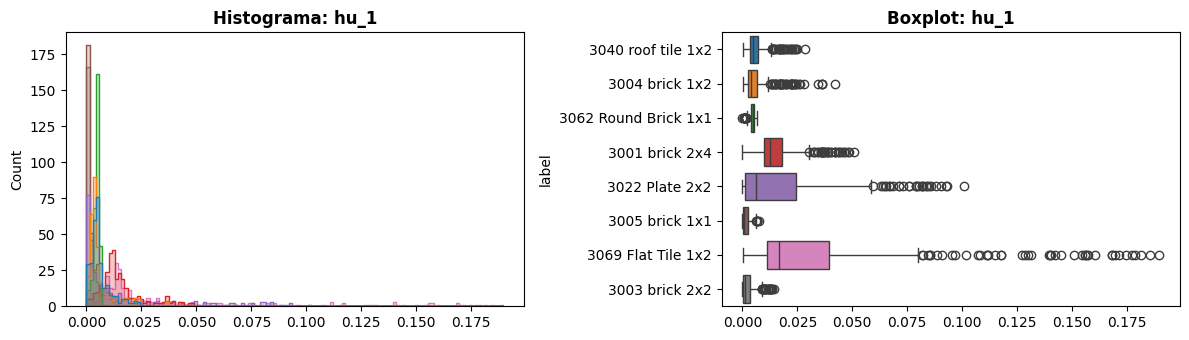

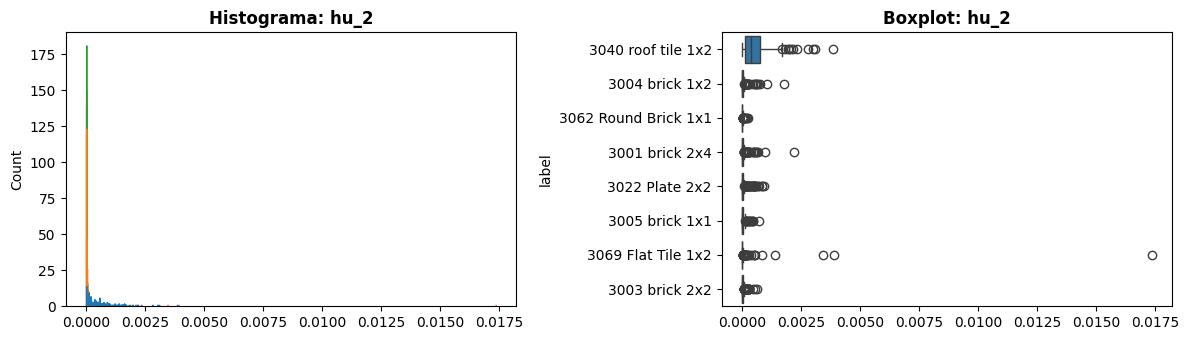

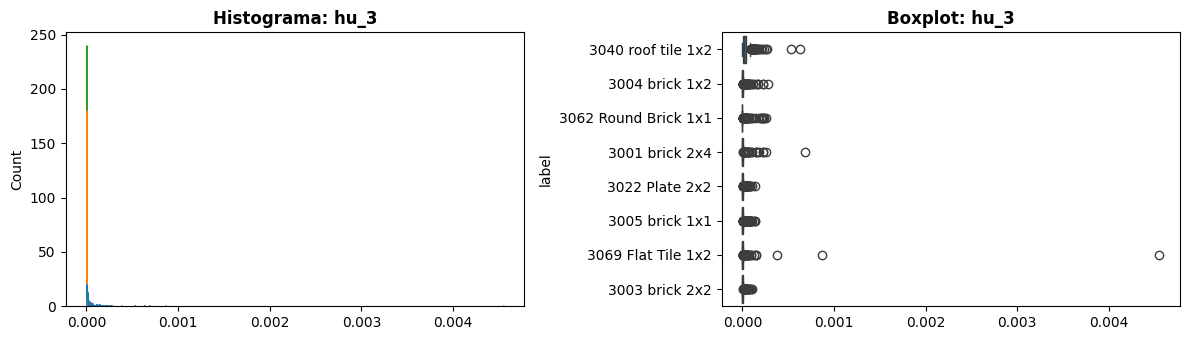

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

caracteristicas = [
    'area',
    'circularidade',
    'altura',
    'largura',
    'hu_0',
    'hu_1',
    'hu_2',
    'hu_3',
    'hu_4',
    'hu_5',
    'hu_6'
]

# Itera sobre cada característica, criando e destruindo a figura individualmente
for feat in caracteristicas:
    # Figura pequena dedicada apenas à característica atual (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    # 1. Histograma (Esquerda)
    sns.histplot(
        data=df_final,
        x=feat,
        hue='label',
        kde=False,  # Altere para True se o dataset for pequeno/médio
        element='step',
        common_norm=False,
        ax=axes[0]
    )
    axes[0].set_title(f'Histograma: {feat}', fontweight='bold')
    axes[0].set_xlabel('')

    # Remove legenda interna do histplot para economizar renderização
    if axes[0].get_legend():
        axes[0].get_legend().remove()

    # 2. Boxplot (Direita)
    sns.boxplot(
        data=df_final,
        x=feat,
        y='label',
        hue='label',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title(f'Boxplot: {feat}', fontweight='bold')
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()

    # CRÍTICO: Libera explicitamente a memória da figura atual do buffer do Matplotlib
    plt.close(fig)

In [ ]:
caract_tabla = ['area', 'altura', 'largura', 'circularidade']

tabela_limpa = (
    df_final.groupby('label')[caract_tabla]
    .agg(['mean', 'std', 'median'])
    .round(2)
)

display(tabela_limpa)

## Track B — Clasificación a partir de datos tabulares

Se te entrega la **ficha técnica** de cada pieza en `piezas_dataset.csv` (una fila por imagen del
dataset anterior; comparten la columna `filename`). La siguiente celda la carga y muestra las primeras
filas.

> **Ojo con el orden de las filas:** `df` (imágenes) y `df_tab` (ficha técnica) **no** tienen por
> qué quedar alineados fila a fila. Cruza siempre por `filename`, nunca por posición.


In [ ]:
# === Datos tabulares: carga del dataset entregado ===
df_tab = pd.read_csv('piezas_dataset.csv')
print('Dimensiones:', df_tab.shape)
df_tab.head(10)

### Tu desarrollo — Track B

Implementa aquí: análisis/descripción del dataset (con gráficos y/o tablas), limpieza (justificada),
selección de características (evitando *data leakage*) y el entrenamiento y comparación de los 4 modelos.

## Track C — Combinación de ambos mundos

Combina las mejores características de imágenes (Parte 1) y tabulares (Parte 2). Ambos conjuntos comparten
la columna `filename`, úsala para alinearlos. Desarrolla todo tu análisis según el enunciado.

### Tu desarrollo — Track C